In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
     accuracy_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, classification_report
)

from xgboost import XGBClassifier
import joblib

In [9]:
# Preprocessing
df = pd.read_csv('Telco-Customer-Churn.csv')

X = df.drop('Churn', axis = 1)
y = df['Churn'].map({'No':0, 'Yes':1}) # Important to convert to 0-1

# Removing it as it is just an identifier
X = df.drop(['customerID', 'Churn'], axis=1)

# Converting total charges to numeric
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X['TotalCharges'].fillna(X['TotalCharges'].median(), inplace=True)

# Encoding the categorical features
X = pd.get_dummies(X, drop_first=True)

C:\Users\Anay Duggal\AppData\Local\Temp\ipykernel_2688\2443774510.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X['TotalCharges'].fillna(X['TotalCharges'].median(), inplace=True)


In [10]:
# Splitting the data

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, 
                                                    random_state=42, stratify=y)


In [11]:
# Baseline XGBoost model

xgb_baseline = XGBClassifier(
    eval_metric = 'logloss',
    random_state = 42
)

xgb_baseline.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
# Evaluating baseline

y_pred = xgb_baseline.predict(X_test)
y_proba = xgb_baseline.predict_proba(X_test)[:, 1]

print("Baseline XGBoost Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba):.4f}")
print("\n", classification_report(y_test, y_pred))

Baseline XGBoost Results:
Accuracy:  0.7878
Recall:    0.5214
Precision: 0.6190
AUC:       0.8225

               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [15]:
# Handling class imbalance using scale_pos_weight in XGBoost

# Count the number of negative (0) and positive (1) samples
neg, pos = np.bincount(y_train)

# Calculate the weight for the positive class
# Formula: Number of negative samples / Number of positive samples
scale_pos_weight = neg / pos

# Display the calculated class weight
print(f'scale_pos_weight = {scale_pos_weight:.3f}')

# Create the XGBoost classifier with class weighting
xgb_weighted = XGBClassifier(
    eval_metric='logloss',                 # Evaluation metric used during training
    scale_pos_weight=scale_pos_weight,     # Assign higher weight to the minority class
    random_state=42                        # Ensures reproducible results
)

# Train the weighted XGBoost model
xgb_weighted.fit(X_train, y_train)

# Predict the class labels for the test data
y_pred_w = xgb_weighted.predict(X_test)

# Predict the probability of the positive class (Churn = 1)
y_proba_w = xgb_weighted.predict_proba(X_test)[:, 1]

# Display the model performance
print("Weighted XGBoost Results:")

# Percentage of correctly classified samples
print(f"Accuracy:  {accuracy_score(y_test, y_pred_w):.4f}")

# Percentage of actual churn customers correctly identified
print(f"Recall:    {recall_score(y_test, y_pred_w):.4f}")

# Percentage of predicted churn customers that actually churned
print(f"Precision: {precision_score(y_test, y_pred_w):.4f}")

# Area Under the ROC Curve (measures overall classification performance)
print(f"AUC:       {roc_auc_score(y_test, y_proba_w):.4f}")

scale_pos_weight = 2.769
Weighted XGBoost Results:
Accuracy:  0.7672
Recall:    0.6845
Precision: 0.5494
AUC:       0.8219


In [16]:
# GridSearchCV tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

grid_search = GridSearchCV(
    xgb_grid, param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV recall:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV recall: 0.8287625418060202


In [17]:
# Final tuned model evaluation

best_xgb = grid_search.best_estimator_
y_pred_final = best_xgb.predict(X_test)
y_proba_final = best_xgb.predict_proba(X_test)[:, 1]

print("Final Tuned XGBoost Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba_final):.4f}")
print("\n", confusion_matrix(y_test, y_pred_final))

Final Tuned XGBoost Results:
Accuracy:  0.7317
Recall:    0.8075
Precision: 0.4967
AUC:       0.8425

 [[729 306]
 [ 72 302]]


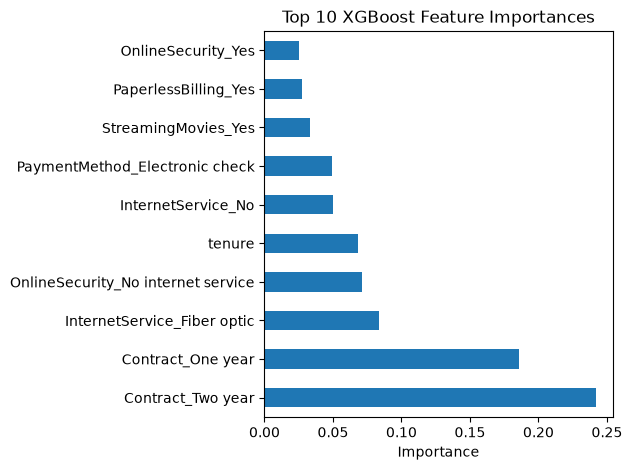

In [18]:
# Feature importance comparison against RF top feature

import matplotlib.pyplot as plt

importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png')
plt.show()

In [19]:
# Saving the model

joblib.dump(best_xgb, 'churn_xgb_model.pkl')

['churn_xgb_model.pkl']